In [71]:
import matplotlib.pyplot as pl
import numpy as np
import ot
from ot.gromov import gromov_wasserstein, fused_gromov_wasserstein

In [72]:
n = 20 
n2 = 30 
sig = 1 
sig2 = 0.1 

np.random.seed(0)

phi = np.arange(n)[:, None]
xs = phi + sig * np.random.randn(n, 1)
ys = np.vstack(
    (np.ones((n // 2, 1)), 0 * np.ones((n // 2, 1)))
) + sig2 * np.random.randn(n, 1)

phi2 = np.arange(n2)[:, None]
xt = phi2 + sig * np.random.randn(n2, 1)
yt = np.vstack(
    (np.ones((n2 // 2, 1)), 0 * np.ones((n2 // 2, 1)))
) + sig2 * np.random.randn(n2, 1)

yt = yt[::-1, :]
p = ot.unif(n)
q = ot.unif(n2)


In [73]:
phi #1D 에서 생성한 규칙적인 위치 

array([[ 0],
       [ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10],
       [11],
       [12],
       [13],
       [14],
       [15],
       [16],
       [17],
       [18],
       [19]])

In [74]:
xs = phi + sig * np.random.randn(n,1)
xs

array([[ 1.8831507 ],
       [-0.34775906],
       [ 0.729515  ],
       [ 3.96939671],
       [ 2.82687659],
       [ 6.94362119],
       [ 5.58638102],
       [ 6.25254519],
       [ 9.92294203],
       [10.48051479],
       [11.86755896],
       [11.90604466],
       [11.13877431],
       [14.91006495],
       [13.73199663],
       [15.8024564 ],
       [16.94725197],
       [16.84498991],
       [18.61407937],
       [19.92220667]])

In [75]:
ys = np.vstack((np.ones((n // 2, 1)), 0 * np.ones((n // 2, 1)))) + sig2 * np.random.randn(n, 1)

ys

array([[ 1.03764255],
       [ 0.89005992],
       [ 1.02982382],
       [ 1.13263859],
       [ 0.93054321],
       [ 0.98503655],
       [ 0.95648464],
       [ 1.18492637],
       [ 1.06722948],
       [ 1.04074618],
       [-0.07699161],
       [ 0.05392492],
       [-0.06743327],
       [ 0.00318306],
       [-0.06358461],
       [ 0.06764333],
       [ 0.05765908],
       [-0.02082988],
       [ 0.03960067],
       [-0.10930615]])

In [76]:
phi2 = np.arange(n2)[:, None]
xt = phi2 + sig * np.random.randn(n2, 1)

print(xt)

[[-1.49125759]
 [ 1.4393917 ]
 [ 2.1666735 ]
 [ 3.63503144]
 [ 6.38314477]
 [ 5.94447949]
 [ 5.08717777]
 [ 8.11701629]
 [ 6.68409259]
 [ 8.5384154 ]
 [ 9.93175839]
 [12.71334272]
 [11.25524518]
 [12.17356146]
 [13.90154748]
 [14.33652171]
 [17.12663592]
 [15.92006849]
 [16.85253135]
 [18.56217996]
 [19.50196755]
 [22.92953205]
 [22.94942081]
 [23.08755124]
 [22.77456448]
 [25.84436298]
 [24.99978465]
 [25.4552289 ]
 [29.18802979]
 [29.31694261]]


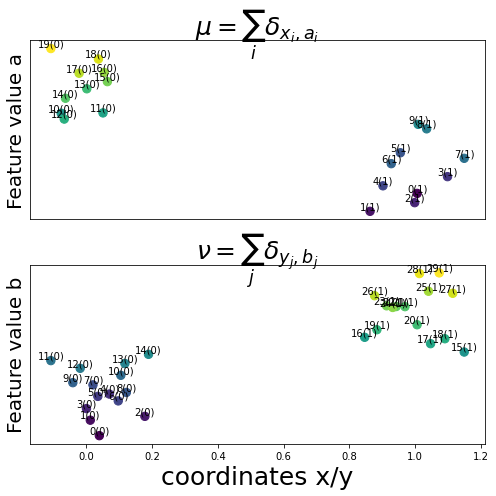

In [77]:
pl.figure(1, (7, 7))

# ---------------------
# Source: μ
# ---------------------
pl.subplot(2, 1, 1)
pl.scatter(ys, xs, c=phi, s=70)

# 각 점에 인덱스 + feature 값 표시
for i in range(n):
    label = f"{i}({int(ys[i, 0] > 0.5)})"   # 1 or 0로 단순화
    pl.text(
        ys[i, 0], xs[i, 0],
        label,
        fontsize=10,
        ha='center', va='bottom'
    )

pl.ylabel("Feature value a", fontsize=20)
pl.title("$\mu=\sum_i \delta_{x_i,a_i}$", fontsize=25, y=1)
pl.xticks(())
pl.yticks(())

# ---------------------
# Target: ν
# ---------------------
pl.subplot(2, 1, 2)
pl.scatter(yt, xt, c=phi2, s=70)

# 타겟 그래프도 인덱스 + feature 값 표시
for j in range(n2):
    label = f"{j}({int(yt[j, 0] > 0.5)})"   # 1 or 0로 단순화
    pl.text(
        yt[j, 0], xt[j, 0],
        label,
        fontsize=10,
        ha='center', va='bottom'
    )

pl.xlabel("coordinates x/y", fontsize=25)
pl.ylabel("Feature value b", fontsize=20)
pl.title("$\\nu=\sum_j \delta_{y_j,b_j}$", fontsize=25, y=1)
pl.yticks(())
pl.tight_layout()
pl.show()



In [78]:
C1 = ot.dist(xs)
C2 = ot.dist(xt)
M = ot.dist(ys, yt)
w1 = ot.unif(C1.shape[0])
w2 = ot.unif(C2.shape[0])
Got = ot.emd([], [], M)

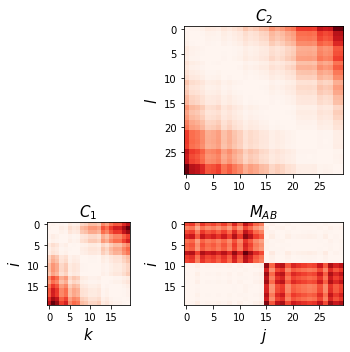

In [79]:
cmap = "Reds"

pl.figure(2, (5, 5))
fs = 15
l_x = [0, 5, 10, 15]
l_y = [0, 5, 10, 15, 20, 25]
gs = pl.GridSpec(5, 5)

ax1 = pl.subplot(gs[3:, :2])

pl.imshow(C1, cmap=cmap, interpolation="nearest")
pl.title("$C_1$", fontsize=fs)
pl.xlabel("$k$", fontsize=fs)
pl.ylabel("$i$", fontsize=fs)
pl.xticks(l_x)
pl.yticks(l_x)

ax2 = pl.subplot(gs[:3, 2:])

pl.imshow(C2, cmap=cmap, interpolation="nearest")
pl.title("$C_2$", fontsize=fs)
pl.ylabel("$l$", fontsize=fs)
pl.xticks(())
pl.yticks(l_y)
ax2.set_aspect("auto")

ax3 = pl.subplot(gs[3:, 2:], sharex=ax2, sharey=ax1)
pl.imshow(M, cmap=cmap, interpolation="nearest")
pl.yticks(l_x)
pl.xticks(l_y)
pl.ylabel("$i$", fontsize=fs)
pl.title("$M_{AB}$", fontsize=fs)
pl.xlabel("$j$", fontsize=fs)
pl.tight_layout()
ax3.set_aspect("auto")
pl.show()

In [80]:
alpha = 0.1

ot.tic()
Gwg, logw = fused_gromov_wasserstein(
    M, C1, C2, p, q, loss_fun="square_loss", alpha=alpha, verbose=True, log=True
)
ot.toc()

# reload_ext WGW
Gg, log = gromov_wasserstein(
    C1, C2, p, q, loss_fun="square_loss", verbose=True, log=True
)

It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|4.549859e+03|0.000000e+00|0.000000e+00
    1|3.531744e+03|2.882753e-01|1.018115e+03
    2|1.485032e+03|1.378228e+00|2.046713e+03
    3|1.485032e+03|0.000000e+00|0.000000e+00
Elapsed time : 0.004381418228149414 s
It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|4.549407e+04|0.000000e+00|0.000000e+00
    1|3.506108e+04|2.975663e-01|1.043299e+04
    2|1.484140e+04|1.362383e+00|2.021968e+04
    3|1.484140e+04|0.000000e+00|0.000000e+00


In [81]:
print("=== 1. Feature Cost (M) Scale ===")
print(f"Max : {M.max():.4f}")
print(f"Min : {M.min():.4f}")
print(f"Mean: {M.mean():.4f}")

print("\n=== 2. Structure Cost (C1, C2) Scale ===")
print(f"C1 (Source) Max : {C1.max():.4f}")
print(f"C2 (Target) Max : {C2.max():.4f}")
print(f"C1 Mean         : {C1.mean():.4f}")

print("\n=== 3. Scale Ratio (Structure / Feature) ===")
print(f"Ratio (C1 Max / M Max): {C1.max() / M.max():.4f}")

=== 1. Feature Cost (M) Scale ===
Max : 1.6693
Min : 0.0000
Mean: 0.5017

=== 2. Structure Cost (C1, C2) Scale ===
C1 (Source) Max : 410.8715
C2 (Target) Max : 949.1452
C1 Mean         : 73.7718

=== 3. Scale Ratio (Structure / Feature) ===
Ratio (C1 Max / M Max): 246.1387


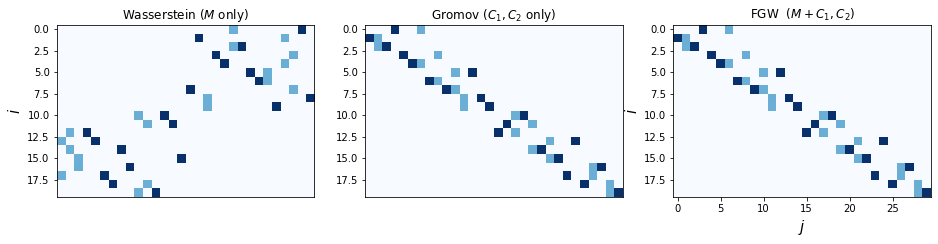

In [82]:
# visu OT matrix
cmap = "Blues"
fs = 15
pl.figure(3, (13, 5))
pl.clf()
pl.subplot(1, 3, 1)
pl.imshow(Got, cmap=cmap, interpolation="nearest")
pl.ylabel("$i$", fontsize=fs)
pl.xticks(())

pl.title("Wasserstein ($M$ only)")

pl.subplot(1, 3, 2)
pl.imshow(Gg, cmap=cmap, interpolation="nearest")
pl.title("Gromov ($C_1,C_2$ only)")
pl.xticks(())
pl.subplot(1, 3, 3)
pl.imshow(Gwg, cmap=cmap, interpolation="nearest")
pl.title("FGW  ($M+C_1,C_2$)")

pl.xlabel("$j$", fontsize=fs)
pl.ylabel("$i$", fontsize=fs)

pl.tight_layout()
pl.show()

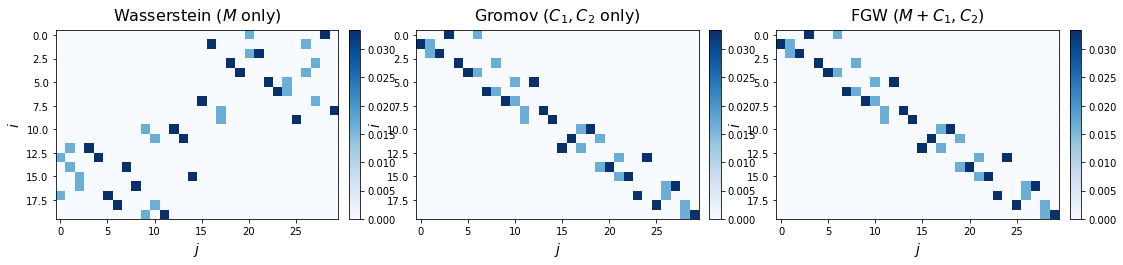

In [83]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np

def plot_plan(ax, matrix, title):
    im = ax.imshow(matrix, cmap="Blues", interpolation="nearest")
    ax.set_title(title, fontsize=16, pad=10)
    ax.set_xlabel("$j$", fontsize=14)
    ax.set_ylabel("$i$", fontsize=14)

    # --- Colorbar aligned cleanly ---
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.15)
    cb = plt.colorbar(im, cax=cax)
    cb.ax.tick_params(labelsize=10)

    return ax


# --- Main figure layout ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

plot_plan(axes[0], Got, "Wasserstein ($M$ only)")
plot_plan(axes[1], Gg, "Gromov ($C_1, C_2$ only)")
plot_plan(axes[2], Gwg, "FGW ($M + C_1, C_2$)")

plt.show()


In [84]:
# --- 4. Graph Matching 시각화 함수 (NumPy 전용) ---
def plot_graph_matching_numpy(xs, ys, xt, yt, Pi, title="Graph Matching"):
    # 차원 축소 (N, 1) -> (N,)
    xs = xs.squeeze()
    ys = ys.squeeze()
    xt = xt.squeeze()
    yt = yt.squeeze()
    pi = Pi # 이미 numpy

    # Target 그래프를 오른쪽으로 이동시켜서 그리기
    x_shift = xs.max() - xt.min() + 5.0 
    xt_shifted = xt + x_shift

    plt.figure(figsize=(14, 6))
    ax = plt.gca()

    # [1] 연결선 그리기 (매칭된 노드끼리)
    threshold = 1e-4 # 플랜 값이 이보다 큰 경우만 선을 그림
    indices = np.argwhere(pi > threshold)
    
    lines = []
    colors = []
    linewidths = []

    # Plan의 최대값을 기준으로 선의 진하기/굵기 결정
    pi_max = pi.max()

    for i, j in indices:
        p1 = (xs[i], ys[i])
        p2 = (xt_shifted[j], yt[j])
        lines.append([p1, p2])
        
        strength = pi[i, j] / pi_max
        # 매칭이 강할수록 진한 회색/검정색
        colors.append((0.2, 0.2, 0.2, strength * 0.6)) 
        linewidths.append(strength * 2.0)

    lc = mc.LineCollection(lines, colors=colors, linewidths=linewidths, zorder=1)
    ax.add_collection(lc)

    # [2] 노드 그리기 (Feature 값인 ys, yt로 색상 표현)
    # 스케일을 맞추기 위해 vmin, vmax 통일
    vmin = min(ys.min(), yt.min())
    vmax = max(ys.max(), yt.max())
    
    sc1 = plt.scatter(xs, ys, c=ys, cmap='coolwarm', vmin=vmin, vmax=vmax, s=150, edgecolors='k', zorder=2, label='Source')
    sc2 = plt.scatter(xt_shifted, yt, c=yt, cmap='coolwarm', vmin=vmin, vmax=vmax, s=150, edgecolors='k', marker='D', zorder=2, label='Target')

    # [3] 인덱스 텍스트 추가
    for i in range(len(xs)):
        ax.text(xs[i], ys[i]+0.05, str(i), fontsize=9, ha='center', fontweight='bold')
    for i in range(len(xt)):
        ax.text(xt_shifted[i], yt[i]+0.05, str(i), fontsize=9, ha='center', fontweight='bold')

    # 타이틀 및 범위 설정
    plt.title(title, fontsize=18, pad=20)
    plt.axis('off') # 축 숨기기
    
    # 범례 및 설명
    plt.text(xs.mean(), ys.min() - 0.5, "Source Graph\n(Left: Red -> Blue)", ha='center', fontsize=12)
    plt.text(xt_shifted.mean(), yt.min() - 0.5, "Target Graph\n(Right: Blue -> Red)", ha='center', fontsize=12)
    
    cbar = plt.colorbar(sc1, label="Feature Value (Color)", shrink=0.7)
    plt.tight_layout()
    plt.show()

### High Dimensional 일 때에는 어떻게 될까? 

- 당연히 feature vector가 고차원이 되는 만큼 alpha를 암만 키워도 Wasserstein에 가까운 결과로 이어지게 될 전망 


Max value in Structure Matrix C1: 292.10
Max value in Feature Matrix M:    24004.47
Scale Ratio (M / C1):             82.18


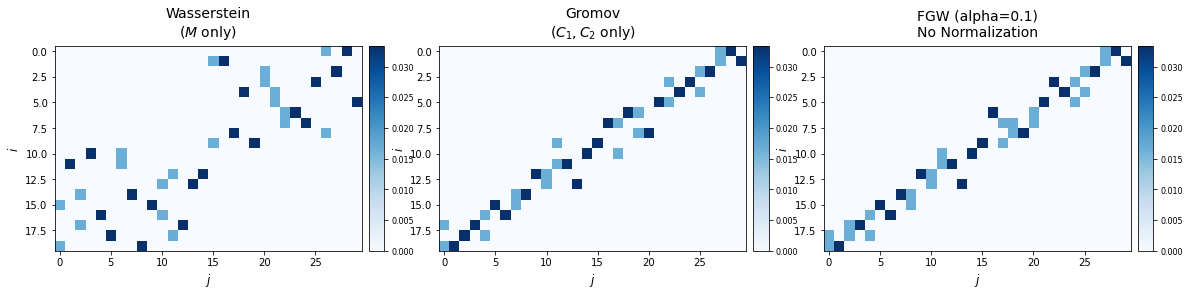

In [86]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import ot
from ot.gromov import gromov_wasserstein, fused_gromov_wasserstein

# -----------------------------------------------------------------------------
# 1. Data Generation
# -----------------------------------------------------------------------------
np.random.seed(42)

n = 20
n2 = 30
dim = 768  # 고차원 Feature

# Structure (Small Scale)
# 1D 상의 위치, 거리는 기껏해야 0 ~ 20 정도
sig = 1
phi = np.arange(n)[:, None]
xs = phi + sig * np.random.randn(n, 1)

phi2 = np.arange(n2)[:, None]
xt = phi2 + sig * np.random.randn(n2, 1)

# Feature (Large Scale due to dimensionality)
# 768차원의 유클리드 거리는 차원이 클수록 값이 커집니다 (Distance Concentration)
base_signal_1 = np.random.randn(1, dim)
base_signal_2 = np.random.randn(1, dim) + 5

ys = np.vstack((
    base_signal_1 + np.random.randn(n // 2, dim), 
    base_signal_2 + np.random.randn(n // 2, dim)
))

yt_raw = np.vstack((
    base_signal_1 + np.random.randn(n2 // 2, dim),
    base_signal_2 + np.random.randn(n2 // 2, dim)
))
yt = yt_raw[::-1, :] # Feature 순서 반전 (Anti-diagonal 유도)

p = ot.unif(n)
q = ot.unif(n2)

# -----------------------------------------------------------------------------
# 2. Compute Matrices (NO Normalization)
# -----------------------------------------------------------------------------
C1 = ot.dist(xs)
C2 = ot.dist(xt)
M = ot.dist(ys, yt)

# [확인용] 스케일 차이 출력
print(f"Max value in Structure Matrix C1: {C1.max():.2f}")
print(f"Max value in Feature Matrix M:    {M.max():.2f}")
print(f"Scale Ratio (M / C1):             {M.max() / C1.max():.2f}")

# -----------------------------------------------------------------------------
# 3. Compute Plans
# -----------------------------------------------------------------------------
# 3-1. Wasserstein
Got = ot.emd(p, q, M)

# 3-2. Gromov-Wasserstein
Gg = gromov_wasserstein(C1, C2, p, q, loss_fun="square_loss", verbose=False)

# 3-3. Fused Gromov-Wasserstein (Extreme Alpha)
# alpha = 0.99로 설정하여 "구조(Structure)"에 99% 가중치를 줍니다.
# 하지만 정규화를 안 했으므로 M의 스케일이 이를 압도할 것입니다.
alpha = 0.1
Gwg = fused_gromov_wasserstein(M, C1, C2, p, q, loss_fun="square_loss", alpha=alpha, verbose=False)

# -----------------------------------------------------------------------------
# 4. Visualization
# -----------------------------------------------------------------------------
def plot_plan(ax, matrix, title):
    im = ax.imshow(matrix, cmap="Blues", interpolation="nearest")
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel("$j$", fontsize=12)
    ax.set_ylabel("$i$", fontsize=12)
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    cb = plt.colorbar(im, cax=cax)
    cb.ax.tick_params(labelsize=8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

plot_plan(axes[0], Got, "Wasserstein\n($M$ only)")
plot_plan(axes[1], Gg, "Gromov\n($C_1, C_2$ only)")
# Title에 실험 조건 명시
plot_plan(axes[2], Gwg, f"FGW (alpha={alpha})\nNo Normalization")

plt.show()

In [87]:
# 실제 GW Loss 항의 최대값 계산
# C1의 최대값과 C2의 최소값(혹은 그 반대)의 차이의 제곱이 최대 비용이 됩니다.
gw_cost_max = (C1.max() - C2.min()) ** 2

print(f"1. Feature Cost (M) Max:      {M.max():,.2f}")
print(f"2. Structure Cost (GW) Max:   {gw_cost_max:,.2f} (Internal Term)")
print(f"3. Actual Ratio (GW / M):     {gw_cost_max / M.max():.2f}")

1. Feature Cost (M) Max:      24,004.47
2. Structure Cost (GW) Max:   85,323.39 (Internal Term)
3. Actual Ratio (GW / M):     3.55


Max value in Structure Matrix C1 (Cosine, Normed): 0.0000
Max value in Feature Matrix M (SqEuclidean):       24004.4701
Scale Ratio (M / C1):                              24004470140698.81


/home/eungyeop/anaconda3/envs/featllm/lib/python3.8/site-packages/ot/optim.py:312: RuntimeWarning: invalid value encountered in scalar divide
  relative_delta_fval = abs_delta_fval / abs(f_val)


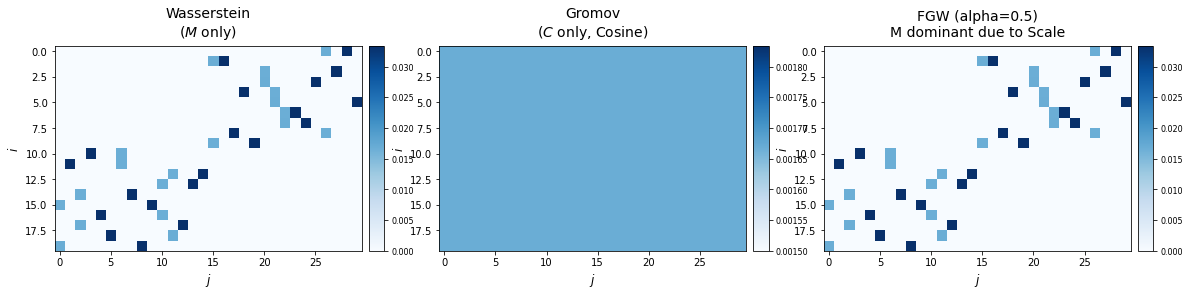

In [88]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import ot
from ot.gromov import gromov_wasserstein, fused_gromov_wasserstein
from scipy.spatial.distance import cdist # Cosine distance 계산을 위해 추가

# -----------------------------------------------------------------------------
# 1. Data Generation
# -----------------------------------------------------------------------------
np.random.seed(42)

n = 20
n2 = 30
dim = 768  # 고차원 Feature

# Structure (xs, xt)
sig = 1
phi = np.arange(n)[:, None]
xs = phi + sig * np.random.randn(n, 1)

phi2 = np.arange(n2)[:, None]
xt = phi2 + sig * np.random.randn(n2, 1)

# Feature (ys, yt) - 768 Dimension
base_signal_1 = np.random.randn(1, dim)
base_signal_2 = np.random.randn(1, dim) + 5

ys = np.vstack((
    base_signal_1 + np.random.randn(n // 2, dim), 
    base_signal_2 + np.random.randn(n // 2, dim)
))

yt_raw = np.vstack((
    base_signal_1 + np.random.randn(n2 // 2, dim),
    base_signal_2 + np.random.randn(n2 // 2, dim)
))
yt = yt_raw[::-1, :] # 순서 반전

p = ot.unif(n)
q = ot.unif(n2)

# -----------------------------------------------------------------------------
# 2. Compute Matrices (Modified)
# -----------------------------------------------------------------------------

# [변경 1] Structure Cost: Cosine Distance (1 - Cosine Similarity)
# 주의: 1D 데이터에서 Cosine은 방향(부호)만 보므로 거의 0에 가깝게 나올 수 있지만,
# 사용자의 의도대로 "작은 스케일"을 만들기 위해 그대로 진행합니다.
C1 = cdist(xs, xs, metric='cosine')
C2 = cdist(xt, xt, metric='cosine')

# [변경 2] Structure Normalization (0~1 사이로 재보정)
# NaN 방지 (0으로 나누는 경우 대비)
if C1.max() > 0: C1 /= C1.max()
if C2.max() > 0: C2 /= C2.max()

# [변경 3] Feature Cost: Squared Euclidean (그대로 유지 -> 값 매우 큼)
M = ot.dist(ys, yt, metric='sqeuclidean') 

# [확인용] 스케일 비교
print(f"Max value in Structure Matrix C1 (Cosine, Normed): {C1.max():.4f}")
print(f"Max value in Feature Matrix M (SqEuclidean):       {M.max():.4f}")
print(f"Scale Ratio (M / C1):                              {M.max() / (C1.max() + 1e-9):.2f}")

# -----------------------------------------------------------------------------
# 3. Compute Plans
# -----------------------------------------------------------------------------
# 3-1. Wasserstein (Feature Only)
Got = ot.emd(p, q, M)

# 3-2. Gromov-Wasserstein (Structure Only)
Gg = gromov_wasserstein(C1, C2, p, q, loss_fun="square_loss", verbose=False)

# 3-3. Fused Gromov-Wasserstein
# alpha를 0.5 (반반)로 주더라도 M이 너무 커서 구조가 무시되는지 확인
alpha = 0.5
Gwg = fused_gromov_wasserstein(M, C1, C2, p, q, loss_fun="square_loss", alpha=alpha, verbose=False)

# -----------------------------------------------------------------------------
# 4. Visualization
# -----------------------------------------------------------------------------
def plot_plan(ax, matrix, title):
    im = ax.imshow(matrix, cmap="Blues", interpolation="nearest")
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel("$j$", fontsize=12)
    ax.set_ylabel("$i$", fontsize=12)
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    cb = plt.colorbar(im, cax=cax)
    cb.ax.tick_params(labelsize=8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

plot_plan(axes[0], Got, "Wasserstein\n($M$ only)")
plot_plan(axes[1], Gg, "Gromov\n($C$ only, Cosine)")
plot_plan(axes[2], Gwg, f"FGW (alpha={alpha})\nM dominant due to Scale")

plt.show()

Max value in Structure Matrix C1 (Cosine of y): 1.0527
Max value in Feature Matrix M (SqEuclidean of y): 24245.1231
Scale Ratio (M / C1): 23032.11


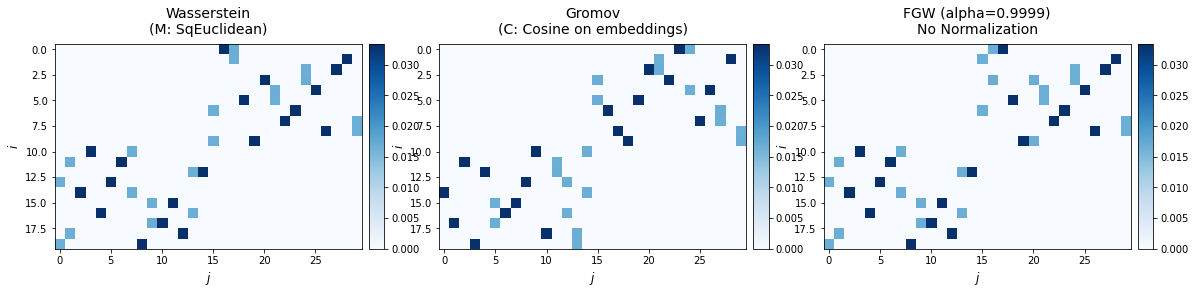


   [정량적 비교] 행렬 간 차이 (Frobenius Norm)
   * 값이 0에 가까울수록 두 Plan이 동일함을 의미
1. Distance (FGW vs Wasserstein): 0.047140
2. Distance (FGW vs Gromov):      0.228522
3. Reference (Wasserstein vs Gromov): 0.229734
--------------------------------------------------
결론: FGW는 Wasserstein 결과에 4.8배 더 가깝습니다.
      -> Feature Scale이 Structure를 압도하고 있습니다.


In [89]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import ot
from ot.gromov import gromov_wasserstein, fused_gromov_wasserstein
from scipy.spatial.distance import cdist

# -----------------------------------------------------------------------------
# 1. Data Generation (Same as before)
# -----------------------------------------------------------------------------
np.random.seed(42)

n = 20
n2 = 30
dim = 768 

# (xs, xt는 이제 구조 계산에 안 씁니다)
base_signal_1 = np.random.randn(1, dim)
base_signal_2 = np.random.randn(1, dim) + 5

ys = np.vstack((
    base_signal_1 + np.random.randn(n // 2, dim), 
    base_signal_2 + np.random.randn(n // 2, dim)
))

yt_raw = np.vstack((
    base_signal_1 + np.random.randn(n2 // 2, dim),
    base_signal_2 + np.random.randn(n2 // 2, dim)
))
yt = yt_raw[::-1, :] # 순서 반전

p = ot.unif(n)
q = ot.unif(n2)

# -----------------------------------------------------------------------------
# 2. Compute Matrices (User's Intent)
# -----------------------------------------------------------------------------

# [핵심 변경] Structure를 "Feature(y) 간의 Cosine 거리"로 정의
# cdist(metric='cosine')은 1 - CosineSimilarity 값을 반환합니다.
# 범위: 0(완전 일치) ~ 2(완전 반대)
C1 = cdist(ys, ys, metric='cosine')
C2 = cdist(yt, yt, metric='cosine')

# [비교 대상] Feature Cost는 그대로 Squared Euclidean (값 큼)
M = ot.dist(ys, yt, metric='sqeuclidean')

# 정규화 없이(NO Normalization) 스케일 비교
print(f"Max value in Structure Matrix C1 (Cosine of y): {C1.max():.4f}")
print(f"Max value in Feature Matrix M (SqEuclidean of y): {M.max():.4f}")
print(f"Scale Ratio (M / C1): {M.max() / C1.max():.2f}")

# -----------------------------------------------------------------------------
# 3. Compute Plans
# -----------------------------------------------------------------------------
# 3-1. Wasserstein (M only)
Got = ot.emd(p, q, M)

# 3-2. Gromov (C only) - 이제 C도 y로 만들었으니 의미가 있습니다!
Gg = gromov_wasserstein(C1, C2, p, q, loss_fun="square_loss", verbose=False)

# 3-3. FGW (Both) - alpha=0.5
alpha = 0.9999
Gwg = fused_gromov_wasserstein(M, C1, C2, p, q, loss_fun="square_loss", alpha=alpha, verbose=False)

# -----------------------------------------------------------------------------
# 4. Visualization
# -----------------------------------------------------------------------------
def plot_plan(ax, matrix, title):
    im = ax.imshow(matrix, cmap="Blues", interpolation="nearest")
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel("$j$", fontsize=12)
    ax.set_ylabel("$i$", fontsize=12)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    cb = plt.colorbar(im, cax=cax)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

plot_plan(axes[0], Got, "Wasserstein\n(M: SqEuclidean)")
plot_plan(axes[1], Gg, "Gromov\n(C: Cosine on embeddings)")
plot_plan(axes[2], Gwg, f"FGW (alpha={alpha})\nNo Normalization")

plt.show()


# -----------------------------------------------------------------------------
# 5. Quantitative Comparison (Matrix Differences)
# -----------------------------------------------------------------------------
print("\n" + "="*50)
print("   [정량적 비교] 행렬 간 차이 (Frobenius Norm)")
print("   * 값이 0에 가까울수록 두 Plan이 동일함을 의미")
print("="*50)

# Difference calculation
diff_W_FGW = np.linalg.norm(Gwg - Got) # FGW와 Wasserstein의 차이
diff_G_FGW = np.linalg.norm(Gwg - Gg)  # FGW와 Gromov의 차이
diff_W_G   = np.linalg.norm(Got - Gg)  # Wasserstein과 Gromov 자체의 차이 (기준점)

print(f"1. Distance (FGW vs Wasserstein): {diff_W_FGW:.6f}")
print(f"2. Distance (FGW vs Gromov):      {diff_G_FGW:.6f}")
print(f"3. Reference (Wasserstein vs Gromov): {diff_W_G:.6f}")

print("-" * 50)
# 해석
if diff_W_FGW < diff_G_FGW:
    ratio = diff_G_FGW / (diff_W_FGW + 1e-9)
    print(f"결론: FGW는 Wasserstein 결과에 {ratio:.1f}배 더 가깝습니다.")
    print("      -> Feature Scale이 Structure를 압도하고 있습니다.")
else:
    ratio = diff_W_FGW / (diff_G_FGW + 1e-9)
    print(f"결론: FGW는 Gromov 결과에 {ratio:.1f}배 더 가깝습니다.")
    print("      -> Structure 정보가 반영되고 있습니다.")

In [90]:
### 지금 아래 코드가 표준임!!

Start Training (UMAP Trajectory Enabled)...
--------------------------------------------------
Epoch    0 | FGW Loss: 0.434793
   [RAW COST SCALE COMPARISON]
   1. Feature Cost (M) Max:      9.16
   2. Structure Cost (GW) Max:   0.03 (Internal Term)
   3. Actual Ratio (GW / M):     0.00
--------------------------------------------------
Epoch  100 | FGW Loss: 0.195895
   [RAW COST SCALE COMPARISON]
   1. Feature Cost (M) Max:      17.80
   2. Structure Cost (GW) Max:   2.64 (Internal Term)
   3. Actual Ratio (GW / M):     0.15
--------------------------------------------------
Epoch  200 | FGW Loss: 0.145752
   [RAW COST SCALE COMPARISON]
   1. Feature Cost (M) Max:      21.93
   2. Structure Cost (GW) Max:   8.77 (Internal Term)
   3. Actual Ratio (GW / M):     0.40
--------------------------------------------------
Epoch  300 | FGW Loss: 0.121455
   [RAW COST SCALE COMPARISON]
   1. Feature Cost (M) Max:      24.89
   2. Structure Cost (GW) Max:   17.18 (Internal Term)
   3. Actual R

/home/eungyeop/anaconda3/envs/featllm/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


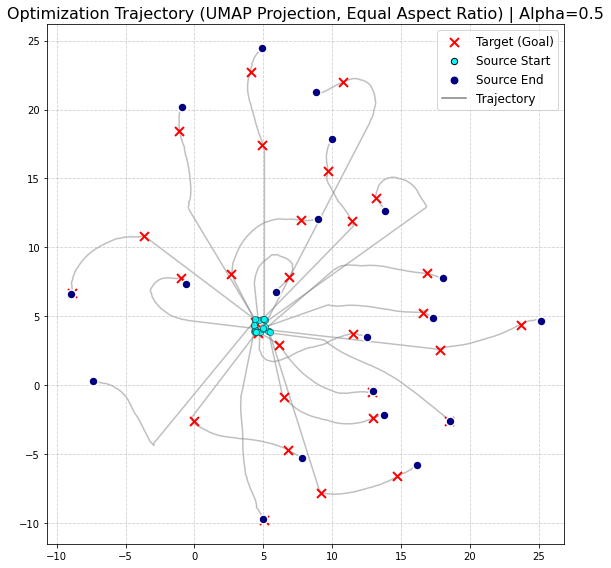

In [91]:
import torch
import torch.optim as optim
import ot
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE 
# UMAP 라이브러리가 설치되어 있어야 합니다 (pip install umap-learn)
# UMAP 모듈 임포트 시도를 try/except로 감싸 안정성을 확보합니다.
try:
    import umap.umap_ as umap
    UMAP_AVAILABLE = True
except ImportError:
    try:
        import umap
        UMAP_AVAILABLE = True
    except ImportError:
        print("UMAP not found. Falling back to PCA for visualization.")
        UMAP_AVAILABLE = False


# -----------------------------------------------------------------------------
# 1. Setup Data
# -----------------------------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)

n_source = 20
n_target = 30
dim = 768
EPSILON = 1e-9 # 0으로 나누는 것을 방지하기 위한 작은 값

# [Target Data]: Target 클러스터를 중앙에 모아 UMAP이 더 잘 분리하도록 유도
target_emb = torch.randn(n_target, dim) * 0.1 
# target_emb[:n_target//2] += 2.0 # Cluster 1: +2.0
# target_emb[n_target//2:] -= 2.0 # Cluster 2: -2.0

# Source Data (Learnable): Target과 겹쳐서 시작
source_emb = torch.randn(n_source, dim, requires_grad=True)

with torch.no_grad():
    source_emb.data *= 0.01 # 시작 분산을 극도로 작게 (거의 한 점)

# Distribution weights
p = ot.unif(n_source, type_as=source_emb)
q = ot.unif(n_target, type_as=target_emb)

# -----------------------------------------------------------------------------
# 2. Training Loop (Robust Normalization)
# -----------------------------------------------------------------------------
optimizer = optim.SGD([source_emb], lr=0.5) 

print("Start Training (UMAP Trajectory Enabled)...")
loss_history = []
source_history = [] 
alpha = 0.5

# 초기 상태
source_history.append(source_emb.detach().cpu().numpy().copy())

# [핵심 수정] 최종 수렴 확인을 위해 5000 Epoch으로 늘림
n_epochs = 5000
for epoch in range(n_epochs):
    optimizer.zero_grad()
    
    # --- Matrix Computation ---
    M_raw = ot.dist(source_emb, target_emb)
    C1_raw = ot.dist(source_emb, source_emb)
    C2_raw = ot.dist(target_emb, target_emb)
    
    # Robust Max Normalization (NaN 방지)
    M = M_raw / (M_raw.max() + EPSILON) 
    C1 = C1_raw / (C1_raw.max() + EPSILON)
    C2 = C2_raw / (C2_raw.max() + EPSILON)
    
    # --- FGW Loss ---
    fgw_loss = ot.gromov.fused_gromov_wasserstein2(
        M, C1, C2, p, q,
        loss_fun='square_loss', alpha=alpha
    )
    
    if torch.isnan(fgw_loss):
        print("Loss is NaN! Stopping training.")
        break

    # --- Update ---
    fgw_loss.backward()
    optimizer.step()
    
    loss_history.append(fgw_loss.item())
    
    # [로그 출력]
    if epoch % 100 == 0:
        raw_m_max = M_raw.max().item()
        gw_max_cost = (C1_raw.max().item() - C2_raw.min().item())**2
        actual_ratio = gw_max_cost / (raw_m_max + EPSILON)
        
        print("-" * 50)
        print(f"Epoch {epoch:4d} | FGW Loss: {fgw_loss.item():.6f}")
        print("   [RAW COST SCALE COMPARISON]")
        print(f"   1. Feature Cost (M) Max:      {raw_m_max:,.2f}")
        print(f"   2. Structure Cost (GW) Max:   {gw_max_cost:,.2f} (Internal Term)")
        print(f"   3. Actual Ratio (GW / M):     {actual_ratio:,.2f}")
        # 매 스텝 저장
        source_history.append(source_emb.detach().cpu().numpy().copy())

# 최종 상태
source_history.append(source_emb.detach().cpu().numpy().copy())
print("-" * 50)
print(f"Training finished. Final Loss: {loss_history[-1]:.6f}")


# -----------------------------------------------------------------------------
# 3. Visualization: Trajectories (UMAP 2D Projection - ALL DATA)
# -----------------------------------------------------------------------------
print("Visualizing Trajectories with UMAP (Optimized Scaling)...")
projection_method = "UMAP"

# [핵심 수정] 모든 시점의 Source와 Target을 합쳐서 UMAP을 단 1회 수행합니다.
# 이렇게 해야 모든 궤적이 하나의 일관된 좌표계를 가집니다.
all_data = np.vstack(source_history + [target_emb.numpy()])

if UMAP_AVAILABLE:
    # UMAP 변환기 (두 클러스터가 합쳐진 것을 보여줄 것입니다)
    reducer = umap.UMAP(n_neighbors=5, min_dist=0.3, n_components=2, random_state=42)
    data_2d = reducer.fit_transform(all_data)
else:
    # UMAP이 실패하면 PCA로 대체 (이전의 안정적인 fallback)
    pca = PCA(n_components=2)
    data_2d = pca.fit_transform(all_data)
    projection_method = "PCA"

# 데이터 분리
target_2d = data_2d[-n_target:]
source_2d_history = []
start_idx = 0
n_snapshots = len(source_history)
for _ in range(n_snapshots):
    end_idx = start_idx + n_source
    source_2d_history.append(data_2d[start_idx:end_idx])
    start_idx = end_idx

source_2d_history = np.array(source_2d_history) 

# 그래프 그리기
plt.figure(figsize=(12, 8))
ax = plt.gca() # 현재 축을 가져옵니다.

# 1. Target (Goal) - 빨간색 X
plt.scatter(target_2d[:, 0], target_2d[:, 1], c='red', marker='x', s=80, linewidths=2, label='Target (Goal)', zorder=2)

# 2. Source Trajectories
for i in range(n_source):
    traj = source_2d_history[:, i, :]
    
    # 이동 경로 선 (진한 회색)
    plt.plot(traj[:, 0], traj[:, 1], color='gray', alpha=0.5, linewidth=1.5, zorder=1)
    
    # 시작점 (하늘색)
    plt.scatter(traj[0, 0], traj[0, 1], color='cyan', s=40, alpha=0.8, edgecolors='black', linewidth=0.5, zorder=3)
    
    # 끝점 (진한 파랑)
    plt.scatter(traj[-1, 0], traj[-1, 1], color='navy', s=80, edgecolors='white', linewidth=1.5, zorder=4)

# [핵심 수정] UMAP 시각화에서는 축 비율을 1:1로 강제합니다.
ax.set_aspect('equal', adjustable='box') 

# Legend (가짜 핸들 생성)
plt.scatter([], [], c='cyan', s=40, edgecolors='black', label='Source Start')
plt.scatter([], [], c='navy', s=80, edgecolors='white', label='Source End')
plt.plot([], [], color='gray', linewidth=1.5, label='Trajectory')

plt.title(f"Optimization Trajectory ({projection_method} Projection, Equal Aspect Ratio) | Alpha={alpha}", fontsize=16)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Start Training (UMAP Trajectory Enabled - Increased Target Variance)...
--------------------------------------------------
Epoch    0 | FGW Loss: 0.024527
   [RAW COST SCALE COMPARISON]
   1. Feature Cost (M) Max:      891.66
   2. Structure Cost (GW) Max:   0.03 (Internal Term)
   3. Actual Ratio (GW / M):    0.00
--------------------------------------------------
Epoch  100 | FGW Loss: 0.047835
   [RAW COST SCALE COMPARISON]
   1. Feature Cost (M) Max:      894.15
   2. Structure Cost (GW) Max:   1.09 (Internal Term)
   3. Actual Ratio (GW / M):    0.00
--------------------------------------------------
Epoch  200 | FGW Loss: 0.062384
   [RAW COST SCALE COMPARISON]
   1. Feature Cost (M) Max:      894.65
   2. Structure Cost (GW) Max:   2.56 (Internal Term)
   3. Actual Ratio (GW / M):    0.00
--------------------------------------------------
Epoch  300 | FGW Loss: 0.064903
   [RAW COST SCALE COMPARISON]
   1. Feature Cost (M) Max:      895.80
   2. Structure Cost (GW) Max:   5.90 (

/home/eungyeop/anaconda3/envs/featllm/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


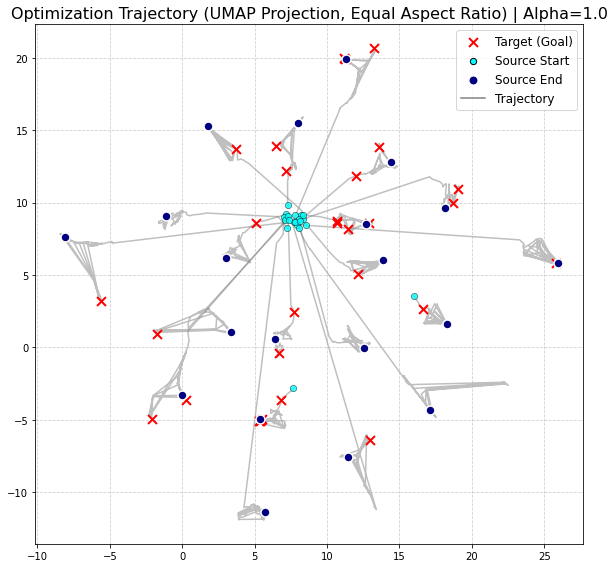

In [ ]:
import torch
import torch.optim as optim
import ot
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
# UMAP 라이브러리가 설치되어 있어야 합니다 (pip install umap-learn)
# UMAP 모듈 임포트 시도를 try/except로 감싸 안정성을 확보합니다.
try:
    import umap.umap_ as umap
    UMAP_AVAILABLE = True
except ImportError:
    try:
        import umap
        UMAP_AVAILABLE = True
    except ImportError:
        print("UMAP not found. Falling back to PCA for visualization.")
        UMAP_AVAILABLE = False


# -----------------------------------------------------------------------------
# 1. Setup Data
# -----------------------------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)

n_source = 20
n_target = 30
dim = 768
EPSILON = 1e-9 # 0으로 나누는 것을 방지하기 위한 작은 값

# [Target Data]: Target 클러스터 내부 분산을 10배 키워서 (0.1 -> 1.0) UMAP이 퍼뜨리도록 유도
target_emb = torch.randn(n_target, dim) * 1.0 # 분산 증대 (이전 0.1)
# target_emb[:n_target//2] += 2.0 # Cluster 1: +2.0
# target_emb[n_target//2:] -= 2.0 # Cluster 2: -2.0

# Source Data (Learnable): Target과 겹쳐서 시작
source_emb = torch.randn(n_source, dim, requires_grad=True)

# 초기화 연산을 .data를 이용해 수행하여 Leaf 상태를 유지합니다.
with torch.no_grad():
    source_emb.data *= 0.01 # 시작 분산을 극도로 작게 (거의 한 점)

# Distribution weights
p = ot.unif(n_source, type_as=source_emb)
q = ot.unif(n_target, type_as=target_emb)

# -----------------------------------------------------------------------------
# 2. Training Loop (Robust Normalization)
# -----------------------------------------------------------------------------
optimizer = optim.SGD([source_emb], lr=0.5) 

print("Start Training (UMAP Trajectory Enabled - Increased Target Variance)...")
loss_history = []
alpha = 1.0 

# 초기 상태
source_history = [source_emb.detach().cpu().numpy().copy()]

# [핵심 수정] 최종 수렴 확인을 위해 5000 Epoch으로 늘림
n_epochs = 5000
for epoch in range(n_epochs):
    optimizer.zero_grad()

    # --- Matrix Computation ---
    M_raw = ot.dist(source_emb, target_emb)
    C1_raw = ot.dist(source_emb, source_emb)
    C2_raw = ot.dist(target_emb, target_emb)

    # Robust Max Normalization (NaN 방지)
    M = M_raw / (M_raw.max() + EPSILON) 
    C1 = C1_raw / (C1_raw.max() + EPSILON)
    C2 = C2_raw / (C2_raw.max() + EPSILON)

    # --- FGW Loss ---
    fgw_loss = ot.gromov.fused_gromov_wasserstein2(
    M, C1, C2, p, q,
    loss_fun='square_loss', alpha=alpha
    )

    if torch.isnan(fgw_loss):
        print("Loss is NaN! Stopping training.")
        break

    # --- Update ---
    fgw_loss.backward()
    optimizer.step()

    loss_history.append(fgw_loss.item())

    # [로그 출력]
    if epoch % 100 == 0:
        raw_m_max = M_raw.max().item()
        gw_max_cost = (C1_raw.max().item() - C2_raw.min().item())**2
        actual_ratio = gw_cost_max / (raw_m_max + EPSILON)
        
        print("-" * 50)
        print(f"Epoch {epoch:4d} | FGW Loss: {fgw_loss.item():.6f}")
        print("   [RAW COST SCALE COMPARISON]")
        print(f"   1. Feature Cost (M) Max:      {raw_m_max:,.2f}")
        print(f"   2. Structure Cost (GW) Max:   {gw_max_cost:,.2f} (Internal Term)")
        print(f"   3. Actual Ratio (GW / M):    {actual_ratio:,.2f}")
        # 매 스텝 저장
        source_history.append(source_emb.detach().cpu().numpy().copy())

# 최종 상태
source_history.append(source_emb.detach().cpu().numpy().copy())
print("-" * 50)
print(f"Training finished. Final Loss: {loss_history[-1]:.6f}")


# -----------------------------------------------------------------------------
# 3. Visualization: Trajectories (UMAP 2D Projection - ALL DATA)
# -----------------------------------------------------------------------------
print("Visualizing Trajectories with UMAP (Optimized Scaling)...")
projection_method = "UMAP"

# [핵심 수정] 모든 시점의 Source와 Target을 합쳐서 UMAP을 단 1회 수행합니다.
all_data = np.vstack(source_history + [target_emb.numpy()])

if UMAP_AVAILABLE:
    # UMAP 변환기 (두 클러스터가 합쳐진 것을 보여줄 것입니다)
    reducer = umap.UMAP(n_neighbors=5, min_dist=0.3, n_components=2, random_state=42)
    data_2d = reducer.fit_transform(all_data)
else:
    # UMAP이 실패하면 PCA로 대체 (이전의 안정적인 fallback)
    pca = PCA(n_components=2)
    data_2d = pca.fit_transform(all_data)
    projection_method = "PCA"

# 데이터 분리
target_2d = data_2d[-n_target:]
source_2d_history = []
start_idx = 0
n_snapshots = len(source_history)
for _ in range(n_snapshots):
    end_idx = start_idx + n_source
    source_2d_history.append(data_2d[start_idx:end_idx])
    start_idx = end_idx

source_2d_history = np.array(source_2d_history) 

# 그래프 그리기
plt.figure(figsize=(12, 8))
ax = plt.gca() # 현재 축을 가져옵니다.

# 1. Target (Goal) - 빨간색 X
plt.scatter(target_2d[:, 0], target_2d[:, 1], c='red', marker='x', s=80, linewidths=2, label='Target (Goal)', zorder=2)

# 2. Source Trajectories
for i in range(n_source):
    traj = source_2d_history[:, i, :]

    # 이동 경로 선 (진한 회색)
    plt.plot(traj[:, 0], traj[:, 1], color='gray', alpha=0.5, linewidth=1.5, zorder=1)

    # 시작점 (하늘색)
    plt.scatter(traj[0, 0], traj[0, 1], color='cyan', s=40, alpha=0.8, edgecolors='black', linewidth=0.5, zorder=3)

    # 끝점 (진한 파랑)
    plt.scatter(traj[-1, 0], traj[-1, 1], color='navy', s=80, edgecolors='white', linewidth=1.5, zorder=4)

# [핵심 수정] UMAP/PCA 시각화에서는 축 비율을 1:1로 강제합니다.
ax.set_aspect('equal', adjustable='box') 

# Legend (가짜 핸들 생성)
plt.scatter([], [], c='cyan', s=40, edgecolors='black', label='Source Start')
plt.scatter([], [], c='navy', s=80, edgecolors='white', label='Source End')
plt.plot([], [], color='gray', linewidth=1.5, label='Trajectory')

plt.title(f"Optimization Trajectory ({projection_method} Projection, Equal Aspect Ratio) | Alpha={alpha}", fontsize=16)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### Pytorch FGW

In [ ]:
import torch
import torch.optim as optim
import ot
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.axes_grid1 import make_axes_locatable

# UMAP 확인
try:
    import umap.umap_ as umap
    UMAP_AVAILABLE = True
except ImportError:
    try:
        import umap
        UMAP_AVAILABLE = True
    except ImportError:
        print("UMAP not found. Falling back to PCA.")
        UMAP_AVAILABLE = False

# -----------------------------------------------------------------------------
# 1. Setup Data
# -----------------------------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)

n_source = 20
n_target = node.shape[0] # 13
dim = 768
EPSILON = 1e-9 

# [Target Data]
if isinstance(node, np.ndarray):
    target_emb = torch.from_numpy(node).float()
else:
    target_emb = node.detach().clone().float()

# [Target Standardization] (데이터 자체의 특이성 보존을 위해 유지)
# t_mean = target_emb.mean(dim=0)
# t_std = target_emb.std(dim=0) + EPSILON
# target_emb = (target_emb - t_mean) / t_std

# [Target Structure (C2)] Stretched 1-Affinity
attn_matrix = torch.tensor(atts[0], dtype=torch.float32).squeeze()
if attn_matrix.dim() == 3: attn_matrix = attn_matrix.mean(dim=0)
attn_matrix = attn_matrix[1:, 1:] # CLS 제거

# 1. Affinity -> Cost
C2_raw = 1.0 - attn_matrix 
C2_raw.fill_diagonal_(0.0) 

# (옵션) Setup 단계의 Min-Max는 데이터 전처리이므로 유지
c2_min = C2_raw.min()
c2_max = C2_raw.max()
C2_raw = (C2_raw - c2_min) / (c2_max - c2_min + EPSILON)

# [Source Data]
source_emb = torch.randn(n_source, dim, requires_grad=True)
with torch.no_grad():
    source_emb.data *= 0.01 

# Weights
p = ot.unif(n_source, type_as=source_emb)
q = ot.unif(n_target, type_as=source_emb)

# Device
device = source_emb.device
target_emb = target_emb.to(device)
C2_raw = C2_raw.to(device)

# -----------------------------------------------------------------------------
# 2. Training Loop
# -----------------------------------------------------------------------------
optimizer = optim.SGD([source_emb], lr=0.5) 

# Alpha 설정
alpha = 0.9999
n_epochs = 5000

print(f"Start Training (ALL Normalization: OFF, Alpha={alpha})...")
print("Warning: Expecting massive scale imbalance between Feature and Structure.")

loss_history = []
feat_cost_history = []
struc_cost_history = []
source_history = [source_emb.detach().cpu().numpy().copy()]

# Plan 시각화용
snapshot_epochs = [0, 100, 1000, 2500, 4900]
plan_snapshots = {}

for epoch in range(n_epochs):
    optimizer.zero_grad()

    # ----------------------------------------------------------------
    # 1. Feature Cost (M): Euclidean
    # ----------------------------------------------------------------
    # 값 범위: ~3200 (Standardized 768 dim)
    M_raw = ot.dist(source_emb, target_emb)
    
    # ----------------------------------------------------------------
    # 2. Structure Cost (C1): Cosine Distance
    # ----------------------------------------------------------------
    # 값 범위: 0.0 ~ 2.0
    source_norm = torch.nn.functional.normalize(source_emb, p=2, dim=1)
    cosine_sim = torch.mm(source_norm, source_norm.t())
    C1_raw = 1.0 - cosine_sim
    C1_raw = torch.clamp(C1_raw, min=0.0)
    C1_raw.fill_diagonal_(0.0)

    # ----------------------------------------------------------------
    # 3. NO Normalization (Raw Scale Experiment)
    # ----------------------------------------------------------------
    # [핵심] Normalization을 아예 하지 않습니다.
    # M은 3000, C는 1.0인 상태 그대로 들어갑니다.
    M = M_raw 
    C1 = C1_raw 
    C2 = C2_raw 

    # FGW Loss
    fgw_loss = ot.gromov.fused_gromov_wasserstein2(
        M, C1, C2, p, q,
        loss_fun='square_loss', alpha=alpha
    )

    if torch.isnan(fgw_loss):
        print("Loss is NaN! Stopping.")
        break

    fgw_loss.backward()
    optimizer.step()
    loss_history.append(fgw_loss.item())

    # Logging & Stats
    if epoch % 100 == 0:
        with torch.no_grad():
            # Plan T 계산
            T = ot.gromov.fused_gromov_wasserstein(M, C1, C2, p, q, loss_fun='square_loss', alpha=alpha)
            
            # 스냅샷
            if epoch in snapshot_epochs:
                plan_snapshots[epoch] = T.detach().cpu().numpy()

            # Raw Feature Cost
            current_feat_cost = torch.sum(M * T).item()
            
            # Raw Structure Cost
            constC, hC1, hC2 = ot.gromov.init_matrix(C1, C2, p, q, 'square_loss')
            current_struc_cost = ot.gromov.gwloss(constC, hC1, hC2, T).item()
            
            feat_cost_history.append(current_feat_cost)
            struc_cost_history.append(current_struc_cost)
            
            # 가중치가 적용된 '실제 영향력' 비교
            # Normalization이 없으므로 M 값이 그대로 곱해져서 매우 클 것임
            weighted_feat = (1 - alpha) * current_feat_cost
            weighted_struc = alpha * current_struc_cost
            total_weight = weighted_feat + weighted_struc + EPSILON
            
            raw_m_max = M.max().item()
            c1_max_val = C1.max().item()

        print(f"Epoch {epoch:4d} | Total Loss: {fgw_loss.item():.6f}")
        print(f"  [Input Scales] M Max: {raw_m_max:.1f} (Raw) vs C1 Max: {c1_max_val:.4f} (Raw)")
        print(f"  [Contribution] Feat: {weighted_feat:.1f} ({weighted_feat/total_weight:.1%}) vs Struc: {weighted_struc:.4f} ({weighted_struc/total_weight:.1%})")
        
        source_history.append(source_emb.detach().cpu().numpy().copy())

source_history.append(source_emb.detach().cpu().numpy().copy())
print("Training Finished.")

# -----------------------------------------------------------------------------
# 3. Visualization: Trajectories
# -----------------------------------------------------------------------------
print("Visualizing Trajectories...")
target_numpy = target_emb.detach().cpu().numpy()
all_data = np.vstack(source_history + [target_numpy])

if UMAP_AVAILABLE:
    reducer = umap.UMAP(n_neighbors=min(15, n_target-1), min_dist=0.1, n_components=2, random_state=42)
    data_2d = reducer.fit_transform(all_data)
    projection_method = "UMAP"
else:
    pca = PCA(n_components=2)
    data_2d = pca.fit_transform(all_data)
    projection_method = "PCA"

target_2d = data_2d[-n_target:]
source_2d_history = np.array(source_2d_history)
source_2d_history = []
start_idx = 0
n_snapshots = len(source_history)
for _ in range(n_snapshots):
    end_idx = start_idx + n_source
    source_2d_history.append(data_2d[start_idx:end_idx])
    start_idx = end_idx
source_2d_history = np.array(source_2d_history)

plt.figure(figsize=(10, 8))
plt.scatter(target_2d[:, 0], target_2d[:, 1], c='red', marker='x', s=80, label='Target (Goal)', zorder=2)
for i in range(n_source):
    traj = source_2d_history[:, i, :]
    plt.plot(traj[:, 0], traj[:, 1], color='gray', alpha=0.3, linewidth=1)
    plt.scatter(traj[0, 0], traj[0, 1], color='cyan', s=20, zorder=3, edgecolors='k', linewidth=0.5)
    plt.scatter(traj[-1, 0], traj[-1, 1], color='navy', s=60, zorder=4, edgecolors='w', linewidth=1)

plt.gca().set_aspect('equal', adjustable='box')
plt.title(f"Optimization Trajectory ({projection_method}) | Alpha={alpha}, No Norm")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 4. Visualization: Cost Evolution (Dual Axis required due to scale)
# -----------------------------------------------------------------------------
print("Visualizing Cost Evolution (Raw Scales)...")
epochs_range = range(0, n_epochs + 100, 100)[:len(feat_cost_history)]

fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Raw Feature Cost (~Thousands)', color=color1, fontsize=12, fontweight='bold')
ax1.plot(epochs_range, feat_cost_history, color=color1, linewidth=2, label='Feature Cost')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx() 
color2 = 'tab:red'
ax2.set_ylabel('Raw Structure Cost (~Ones)', color=color2, fontsize=12, fontweight='bold')
ax2.plot(epochs_range, struc_cost_history, color=color2, linestyle='--', linewidth=2, label='Structure Cost')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title(f"Cost Evolution (Alpha={alpha}, NO Normalization)", fontsize=16)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 5. Visualization: Transport Plan Snapshots (Improved)
# -----------------------------------------------------------------------------
if plan_snapshots:
    print("Visualizing Transport Plans...")
    
    def plot_single_plan(ax, matrix, title):
        im = ax.imshow(matrix, cmap="Blues", interpolation="nearest", aspect='auto')
        ax.set_title(title, fontsize=12, pad=10)
        ax.set_xlabel("Target Index", fontsize=10)
        ax.set_ylabel("Source Index", fontsize=10)
        ax.tick_params(axis='both', which='major', labelsize=8)

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        cb = plt.colorbar(im, cax=cax)
        cb.ax.tick_params(labelsize=8)
        return ax

    n_snaps = len(plan_snapshots)
    fig, axes = plt.subplots(1, n_snaps, figsize=(5 * n_snaps, 5), constrained_layout=True)
    
    if n_snaps == 1: axes = [axes]
    
    sorted_epochs = sorted(plan_snapshots.keys())
    for i, epoch in enumerate(sorted_epochs):
        plot_single_plan(axes[i], plan_snapshots[epoch], f"Plan (Epoch {epoch})")
    
    plt.suptitle(f"Transport Plan Evolution (Alpha={alpha}, No Norm)", fontsize=16, y=1.02)
    plt.show()